# Chapter 11: When Feature Engineering Fails

**How many principal components does a reduction need before it keeps the label, and what does the variance kept say about that?**

A reduction that keeps 93% of the variance sounds safe. The share of variance says nothing about where the label sits, so the check is the downstream score of the whole reduced pipeline, against the unreduced representation.

*Constructed embeddings; where the label sits is chosen by the generator, and the sizes of these effects are properties of it, not of any pretrained model.*

## The experiment

Constructed 64-dimensional embeddings, 600 training rows and 6,000 new rows, twelve independent embeddings per world. Eight strong directions carry no label. In world A the label sits in two weaker directions just below them; in world B it sits in the two strongest directions. PCA is fitted on training rows, the first k components feed a logistic regression, and AUC is measured on the new rows. The unreduced 64-dimension logistic regression and a shrinkage LDA fitted inside training are the comparators.

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from kaggle_companion.activities._common import clean

SEED = 11
REPLICATES = 12                      # independent constructed embeddings; every estimate is their mean
DIM, N_TRAIN, N_NEW = 64, 600, 6000
GRID = [1, 2, 4, 8, 12, 16, 24, 64]  # component counts for the variance-against-AUC curve


def make_rows(rng, n, scales, signal, rotation):
    """Rows of a 64-dimensional 'embedding'. The label depends on two coordinates (`signal`), then everything is rotated."""
    z = rng.normal(size=(n, DIM)) * scales
    s = z[:, signal] / scales[signal]                       # the two signal coordinates, standardized
    y = (rng.random(n) < 1 / (1 + np.exp(-1.6 * (s[:, 0] + s[:, 1]) / np.sqrt(2)))).astype(int)
    return z @ rotation.T, y


def one_embedding(signal_is_high_variance, seed):
    """Fit on 600 rows, score on 6,000 new rows. Everything fitted (PCA, LDA, logistic regression) sees training rows only."""
    rng = np.random.default_rng(seed)
    rotation, _ = np.linalg.qr(rng.normal(size=(DIM, DIM)))
    scales = np.full(DIM, 0.8)                              # 54 weak background directions
    scales[:8] = 8.0                                        # 8 strong directions that carry no label
    if signal_is_high_variance:
        scales[:2], signal = 12.0, [0, 1]                   # world B: the label sits in the two strongest directions
    else:
        scales[8:10], signal = 1.2, [8, 9]                  # world A: the label sits just below the 8 strong directions
    X, y = make_rows(rng, N_TRAIN, scales, signal, rotation)
    X_new, y_new = make_rows(rng, N_NEW, scales, signal, rotation)
    pca = PCA(DIM).fit(X)                                   # fitted on training rows only
    train, new = pca.transform(X), pca.transform(X_new)
    kept = np.cumsum(pca.explained_variance_ratio_)
    auc = {}
    for k in GRID:
        model = LogisticRegression(max_iter=500).fit(train[:, :k], y)
        auc[k] = roc_auc_score(y_new, model.decision_function(new[:, :k]))
    lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto").fit(X, y)   # supervised, fitted inside training
    return {"kept": {k: kept[k - 1] for k in GRID}, "auc": auc, "lda": roc_auc_score(y_new, lda.decision_function(X_new)),
            "all": auc[DIM]}                                # k = 64 keeps every direction: the unreduced regularized model


def run(components):
    world_a = [one_embedding(False, SEED * 100 + i) for i in range(REPLICATES)]
    world_b = [one_embedding(True, SEED * 100 + 50 + i) for i in range(REPLICATES)]

    def mean(runs, getter):
        return float(np.mean([getter(r) for r in runs]))

    def curve(runs):
        return [[k, mean(runs, lambda r: r["kept"][k]), mean(runs, lambda r: r["auc"][k])] for k in GRID]

    return clean({
        "components": components,
        "variance_kept": mean(world_a, lambda r: r["kept"][components]),
        "label_low_variance": {"pca": mean(world_a, lambda r: r["auc"][components]), "all": mean(world_a, lambda r: r["all"]),
                               "lda": mean(world_a, lambda r: r["lda"]),
                               "per_replicate": [r["auc"][components] for r in world_a]},
        "label_high_variance": {"pca": mean(world_b, lambda r: r["auc"][components]), "all": mean(world_b, lambda r: r["all"]),
                                "lda": mean(world_b, lambda r: r["lda"]),
                                "variance_kept": mean(world_b, lambda r: r["kept"][components]),
                                "per_replicate": [r["auc"][components] for r in world_b]},
        "curve_low": curve(world_a), "curve_high": curve(world_b),
        "replicates": REPLICATES, "train_rows": N_TRAIN, "new_rows": N_NEW, "dimension": DIM,
    })


## Measure it across the control

The control is **principal components kept (k)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch11 import explain

VALUES = [2, 8, 12, 24]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                        2      8     12     24
Components kept                         2      8     12     24
Variance kept (world A)             27.1%  93.3%  94.3%  96.1%
PCA, label in weaker directions     0.503  0.507  0.806  0.803
PCA, label in strongest directions  0.821  0.818  0.817  0.811
Unreduced, 64 dimensions            0.784  0.784  0.784  0.784


## Look at it

The figure shows the default setting, principal components kept (k) = 8.

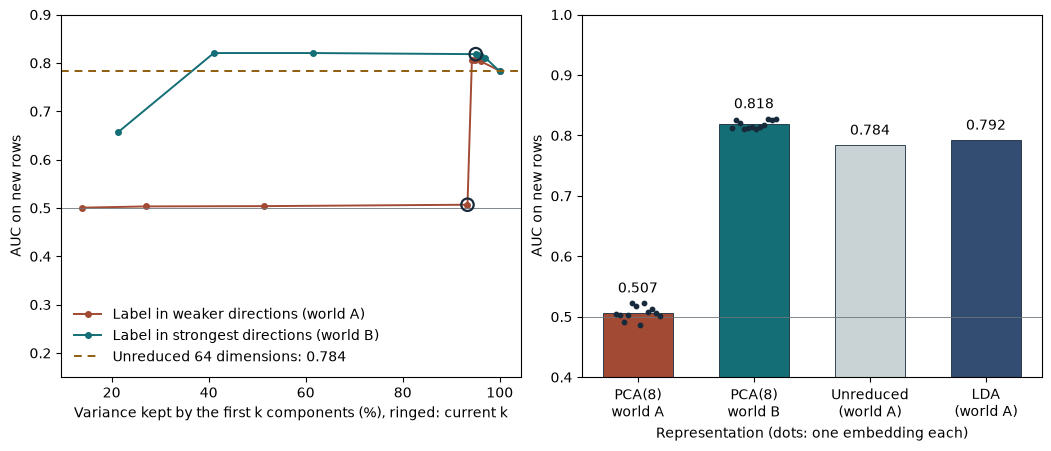

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch11 import draw, NCOLS, HEIGHT

DEFAULT = 8
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 8 components the reduction keeps 93.3% of the variance in world A (95.0% in world B). When the label sits in weaker directions it scores 0.507 AUC on new rows, which is no better than chance; the unreduced model scores 0.784, so 0.507 - 0.784 = -0.277. When the label sits in the strongest directions the same reduction scores 0.818. A shrinkage LDA fitted inside training scores 0.792 without choosing k.

- Variance kept by 8 components, world A: 93.3%.
- World A, PCA minus unreduced: 0.507 - 0.784 = -0.277 AUC.
- World B, PCA minus unreduced: 0.818 - 0.782 = 0.036 AUC.
- World A, LDA minus PCA: 0.792 - 0.507 = 0.285 AUC.

## Apply this to your competition

- Score the unreduced representation with a regularized model first; it is the comparator every reduction must beat.
- Fit PCA inside the training boundary and compare several k on the same assessment, instead of picking k by variance kept.
- Treat variance kept as a size report, never as evidence that the label survived.
- Write the failure down with its artifact, k and score, and name the next test (more components, a supervised reduction fitted inside training).

Book location: Chapter 11, Failure 1: PCA on Pretrained Features.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)